In [2]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel

import shap

In [3]:
df = pd.read_csv("../dataset/churn_clean.csv")

df.drop("customerID", axis=1, inplace=True)

df["Churn"] = df["Churn"].map({"Yes":1,"No":0})

df = pd.get_dummies(df, drop_first=True)

In [4]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [5]:
scaler = StandardScaler()

numeric = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

X_train[numeric] = scaler.fit_transform(X_train[numeric])
X_test[numeric] = scaler.transform(X_test[numeric])

In [6]:
best_model = joblib.load("../model/final_churn_model.pkl")

In [7]:
importance=pd.DataFrame({"Feature":X.columns,
                        "Importance":best_model.feature_importances_})
importance=importance.sort_values("Importance",ascending=False)

In [8]:
importance.head(10)

,Feature,Importance
25,Contract_Two year,0.197328
10,InternetService_Fiber optic,0.185144
24,Contract_One year,0.137740
12,OnlineSecurity_No internet service,0.067954
1,tenure,0.057016
14,OnlineBackup_No internet service,0.053076
11,InternetService_No,0.051734
28,PaymentMethod_Electronic check,0.032447
23,StreamingMovies_Yes,0.022834
9,MultipleLines_Yes,0.019371


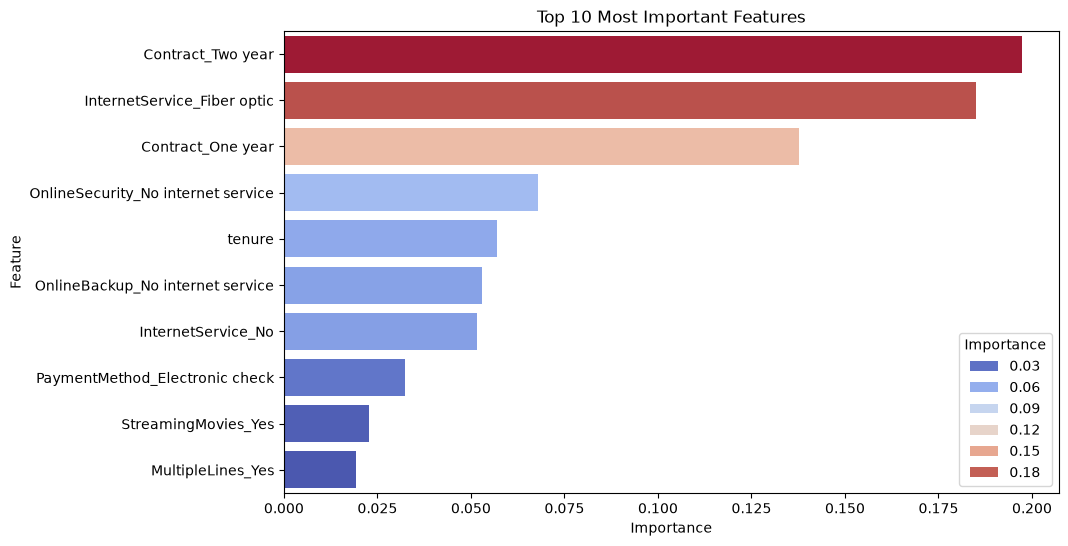

In [11]:
plt.figure(figsize=(10,6))

sns.barplot(data=importance.head(10),x="Importance",y="Feature",hue="Importance",palette="coolwarm")

plt.title("Top 10 Most Important Features")
plt.show()

In [13]:
plt.savefig("../images/feature_importance.png")

<Figure size 640x480 with 0 Axes>

In [14]:
# Feature Selection

selector=SelectFromModel(best_model,threshold="median")
selector.fit(X_train,y_train)

,"estimator estimator: objectThe base estimator from which the transformer is built.This can be both a fitted (if ``prefit`` is set to True)or a non-fitted estimator. The estimator should have a``feature_importances_`` or ``coef_`` attribute after fitting.Otherwise, the ``importance_getter`` parameter should be used.","XGBClassifier...ree=None, ...)"
,"threshold threshold: str or float, default=NoneThe threshold value to use for feature selection. Features whoseabsolute importance value is greater or equal are kept while the othersare discarded. If ""median"" (resp. ""mean""), then the ``threshold`` valueis the median (resp. the mean) of the feature importances. A scalingfactor (e.g., ""1.25*mean"") may also be used. If None and if theestimator has a parameter penalty set to l1, either explicitlyor implicitly (e.g, Lasso), the threshold used is 1e-5.Otherwise, ""mean"" is used by default.",'median'
,"prefit prefit: bool, default=FalseWhether a prefit model is expected to be passed into the constructordirectly or not.If `True`, `estimator` must be a fitted estimator.If `False`, `estimator` is fitted and updated by calling`fit` and `partial_fit`, respectively.",False
,"norm_order norm_order: non-zero int, inf, -inf, default=1Order of the norm used to filter the vectors of coefficients below``threshold`` in the case where the ``coef_`` attribute of theestimator is of dimension 2.",1
,"max_features max_features: int, callable, default=NoneThe maximum number of features to select.- If an integer, then it specifies the maximum number of features to allow.- If a callable, then it specifies how to calculate the maximum number of features allowed. The callable will receive `X` as input: `max_features(X)`.- If `None`, then all features are kept.To only select based on ``max_features``, set ``threshold=-np.inf``... versionadded:: 0.20.. versionchanged:: 1.1 `max_features` accepts a callable.",None
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a ``coef_``attribute or ``feature_importances_`` attribute of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
Name,Type,Value
"estimator_ estimator_: estimatorThe base estimator from which the transformer is built. This attributeexist only when `fit` has been called.- If `prefit=True`, it is a deep copy of `estimator`.- If `prefit=False`, it is a clone of `estimator` and fit on the data passed to `fit` or `partial_fit`.",XGBClassifier,"XGBClassifier...ree=None, ...)"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[<U37](30,)","['SeniorCitizen','tenure','MonthlyCharges',..., 'PaymentMethod_Credit card (automatic)','PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 0.24,int,30
threshold_ threshold_: floatThe threshold value used for feature selection.,float32,np.float32(0.013672952)


In [15]:
selected_features=X_train.columns[selector.get_support()]
print(selected_features)

Index(['tenure', 'MonthlyCharges', 'TotalCharges', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year',
       'PaperlessBilling_Yes', 'PaymentMethod_Electronic check'],
      dtype='str')


In [16]:
from xgboost import XGBClassifier

In [17]:
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

In [18]:
selected_model=XGBClassifier(random_state=41,eval_metric="logloss")

selected_model.fit(X_train_selected,y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [19]:
from sklearn.metrics import accuracy_score

prediction = selected_model.predict(
    X_test_selected
)

print(
    accuracy_score(y_test,prediction)
)

0.7718550106609808


In [20]:
# PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    X_train
)

In [21]:
print(
    pca.explained_variance_ratio_
)

[0.3920216  0.18620969]


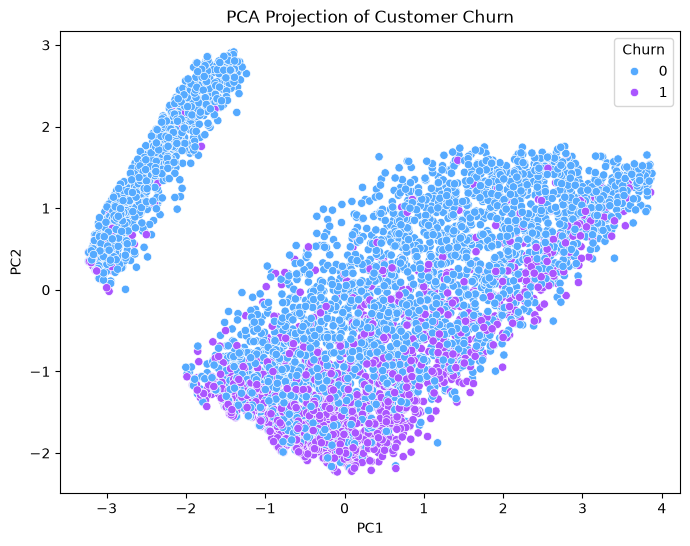

In [25]:
pca_df = pd.DataFrame({
    "PC1":X_pca[:,0],
    "PC2":X_pca[:,1],
    "Churn":y_train.values
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Churn",
    palette="cool"
)

plt.title("PCA Projection of Customer Churn")

plt.show()

In [26]:
# SHAP

explainer = shap.TreeExplainer(
    best_model
)

shap_values = explainer.shap_values(X_test)


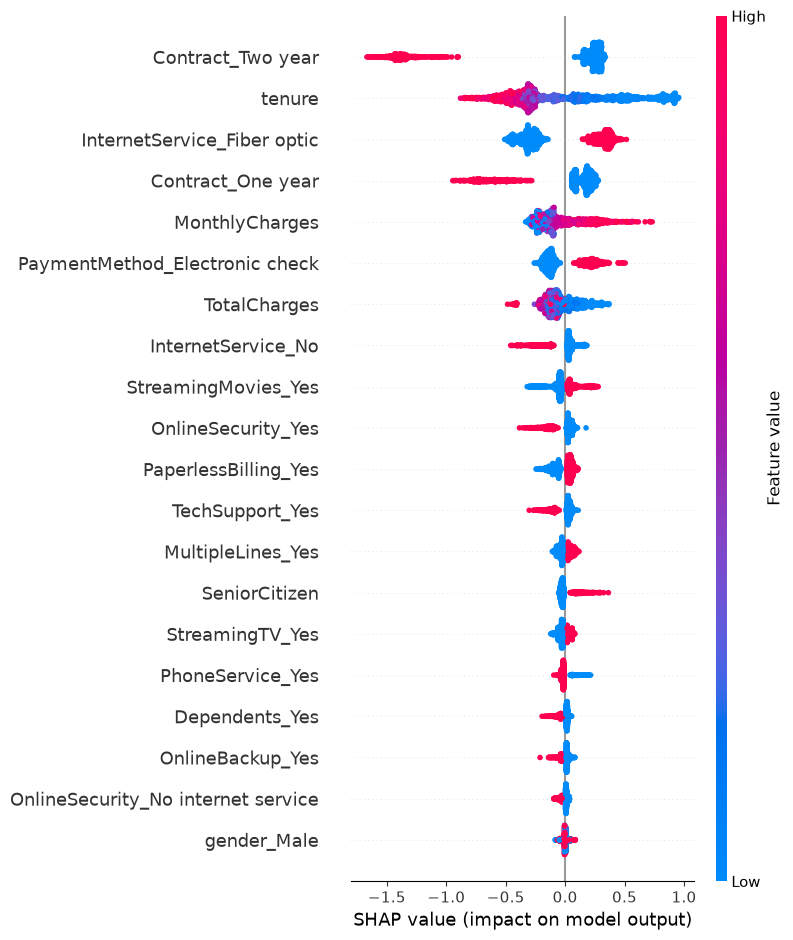

In [27]:
shap.summary_plot(
    shap_values,
    X_test
)

Features at the top are most important.

Red means higher feature values.

Blue means lower feature values.

Points farther from zero have a stronger impact.

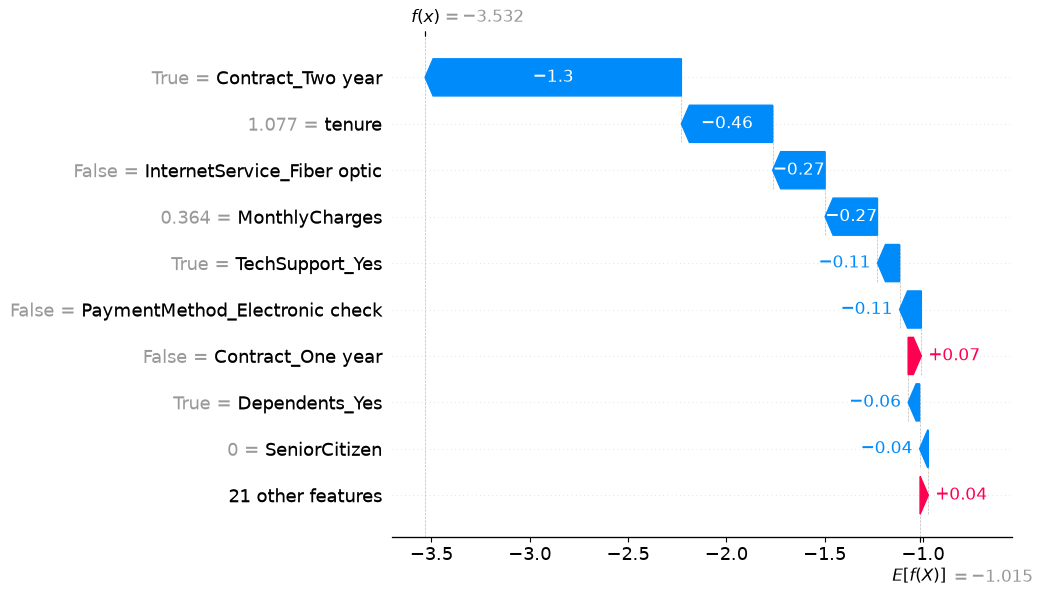

In [28]:
# shap waterfall plot

shap.plots.waterfall(
    explainer(
        X_test.iloc[0:1]
    )[0]
)

The SHAP Waterfall Plot explains the prediction for an individual customer. The strongest factor reducing churn risk was a Two-Year Contract, followed by long customer tenure and having Tech Support. These factors outweighed smaller positive contributions toward churn, resulting in a final prediction that the customer is unlikely to leave

🔵 Blue bars → Push the prediction toward No Churn.

🔴 Red bars → Push the prediction toward Churn.

The length of the bar shows how strongly that feature influenced the prediction.

For example:

Contract_Two year has the longest blue bar, so it had the strongest influence